## Menentukan Pertanyaan

1. Bagaimana tren pencemaran udara di sekitar station?
2. Pada musim apa polusi udara tertinggi?
3. Apakah ada perbedaan tingkat kualitas udara pada siang dan malam hari?
4. Apakah suhu berpengaruh pada pembentukan ozon di lapisan troposfer?(menggunakan metode clustering)

In [1]:
url = "https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/"

## Import Semua Packages yang dipakai

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import datetime

def print_library_versions():
    print("Pandas version:", pd.__version__)
    print("NumPy version:", np.__version__)
    print("Seaborn version:", sns.__version__)
    print("Matplotlib version:", plt.matplotlib.__version__)
    print("SciPy version:", scipy.__version__)

print_library_versions()

Pandas version: 2.2.2
NumPy version: 1.26.4
Seaborn version: 0.13.1
Matplotlib version: 3.7.1
SciPy version: 1.13.1


## Data Wrangling

### Gathering Data

In [58]:
Data_Aotizhongxin = pd.read_csv(url + "PRSA_Data_Aotizhongxin_20130301-20170228.csv")
Data_Changping = pd.read_csv(url + "PRSA_Data_Changping_20130301-20170228.csv")

In [59]:
Data_Aotizhongxin.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [60]:
Data_Changping.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


# Assessing Data

### Data Type

In [61]:
print("\nInfo Dataframe Data_Aotizhongxin:")
print (Data_Aotizhongxin.info())
print("\nInfo Dataframe Data_Changping:")
print(Data_Changping.info())


Info Dataframe Data_Aotizhongxin:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB
None

Info Dataframe Data_Changpi

### missing value

In [62]:
Data_Aotizhongxin.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,925
PM10,718
SO2,935
NO2,1023
CO,1776


In [63]:
Data_Changping.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,774
PM10,582
SO2,628
NO2,667
CO,1521


### data duplikat

In [64]:
print('Dataframe Aotizhongxin:', Data_Aotizhongxin.duplicated().sum())
print("Dataframe Changping:", Data_Changping.duplicated().sum())

Dataframe Aotizhongxin: 0
Dataframe Changping: 0


### statistik deskriptif

In [65]:
print('statistik deskriptif Aotizhongxin:')
print (Data_Aotizhongxin.describe())
print('\nstatistik deskriptif Changping:')
print(Data_Changping.describe())

statistik deskriptif Aotizhongxin:
                 No          year         month           day          hour  \
count  35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
mean   17532.500000   2014.662560      6.522930     15.729637     11.500000   
std    10122.249256      1.177213      3.448752      8.800218      6.922285   
min        1.000000   2013.000000      1.000000      1.000000      0.000000   
25%     8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%    17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%    26298.250000   2016.000000     10.000000     23.000000     17.250000   
max    35064.000000   2017.000000     12.000000     31.000000     23.000000   

              PM2.5          PM10           SO2           NO2            CO  \
count  34139.000000  34346.000000  34129.000000  34041.000000  33288.000000   
mean      82.773611    110.060391     17.375901     59.305833   1262.945145   
std       82.135

- Jumlah data yang tersedia adalah 35064 baris data pada setiap dataset.
- Data berisi data time series mulai tahun 2013 hingga 2017.
- Masih terdapat banyak data kosong yang harus ditangani sebelum melakukan analisi lebih lanjut.
- Tidak terdapat indikasi adanya duplikasi data.
- Data tahun, bulan, hari, dan jam masih dibuat terpisah dalam kolom yang berbeda.

In [66]:
print('Jumlah kolom dan baris Aotizhongxin:')
print (Data_Aotizhongxin.shape)
print('\nJumlah kolom dan baris Changping:')
print(Data_Changping.shape)

Jumlah kolom dan baris Aotizhongxin:
(35064, 18)

Jumlah kolom dan baris Changping:
(35064, 18)


### cleaning data

In [67]:

Data_Aotizhongxin['datetime'] = pd.to_datetime(Data_Aotizhongxin[['year', 'month', 'day']])
Data_Aotizhongxin = Data_Aotizhongxin.drop(columns=['year', 'month','day'])


In [68]:
Data_Changping['datetime'] = pd.to_datetime(Data_Changping[['year', 'month', 'day']])
Data_Changping = Data_Changping.drop(columns=['year', 'month','day'])

In [69]:
print('info dataframe day:')
print (Data_Aotizhongxin.info())
print('\ninfo dataframe hour:')
print(Data_Changping.info())

info dataframe day:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   No        35064 non-null  int64         
 1   hour      35064 non-null  int64         
 2   PM2.5     34139 non-null  float64       
 3   PM10      34346 non-null  float64       
 4   SO2       34129 non-null  float64       
 5   NO2       34041 non-null  float64       
 6   CO        33288 non-null  float64       
 7   O3        33345 non-null  float64       
 8   TEMP      35044 non-null  float64       
 9   PRES      35044 non-null  float64       
 10  DEWP      35044 non-null  float64       
 11  RAIN      35044 non-null  float64       
 12  wd        34983 non-null  object        
 13  WSPM      35050 non-null  float64       
 14  station   35064 non-null  object        
 15  datetime  35064 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(11), int

In [70]:
Data_Aotizhongxin['WSPM'] = Data_Aotizhongxin['WSPM'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['PM2.5'] = Data_Aotizhongxin['PM2.5'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['PM10'] = Data_Aotizhongxin['PM10'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['SO2'] = Data_Aotizhongxin['SO2'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['NO2'] = Data_Aotizhongxin['NO2'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['CO'] = Data_Aotizhongxin['CO'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['O3'] = Data_Aotizhongxin['O3'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['TEMP'] = Data_Aotizhongxin['TEMP'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['PRES'] = Data_Aotizhongxin['PRES'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['DEWP'] = Data_Aotizhongxin['DEWP'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['RAIN'] = Data_Aotizhongxin['RAIN'].interpolate(method='linear', limit_direction='forward')
Data_Aotizhongxin['wd'] = Data_Aotizhongxin['wd'].fillna(value=Data_Aotizhongxin['wd'].mode()[0])

In [71]:
Data_Changping['WSPM'] = Data_Changping['WSPM'].interpolate(method='linear', limit_direction='forward')
Data_Changping['PM2.5'] = Data_Changping['PM2.5'].interpolate(method='linear', limit_direction='forward')
Data_Changping['PM10'] = Data_Changping['PM10'].interpolate(method='linear', limit_direction='forward')
Data_Changping['SO2'] = Data_Changping['SO2'].interpolate(method='linear', limit_direction='forward')
Data_Changping['NO2'] = Data_Changping['NO2'].interpolate(method='linear', limit_direction='forward')
Data_Changping['CO'] = Data_Changping['CO'].interpolate(method='linear', limit_direction='forward')
Data_Changping['O3'] = Data_Changping['O3'].interpolate(method='linear', limit_direction='forward')
Data_Changping['TEMP'] = Data_Changping['TEMP'].interpolate(method='linear', limit_direction='forward')
Data_Changping['PRES'] = Data_Changping['PRES'].interpolate(method='linear', limit_direction='forward')
Data_Changping['DEWP'] = Data_Changping['DEWP'].interpolate(method='linear', limit_direction='forward')
Data_Changping['RAIN'] = Data_Changping['RAIN'].interpolate(method='linear', limit_direction='forward')
Data_Changping['wd'] = Data_Changping['wd'].fillna(value=Data_Changping['wd'].mode()[0])


In [72]:
print("\nJumlah Data kosong pada dataframe Aotizhoxin:")
print(Data_Aotizhongxin.isna().sum())
print("\nJumlah Data kosong pada dataframe Changping:")
print(Data_Changping.isna().sum())


Jumlah Data kosong pada dataframe Aotizhoxin:
No          0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

Jumlah Data kosong pada dataframe Changping:
No          0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


In [73]:
Data_Polusi = pd.concat([Data_Aotizhongxin, Data_Changping], ignore_index=True)
print(Data_Polusi.head())

   No  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  DEWP  RAIN  \
0   1     0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7  1023.0 -18.8   0.0   
1   2     1    8.0   8.0   4.0   7.0  300.0  77.0  -1.1  1023.2 -18.2   0.0   
2   3     2    7.0   7.0   5.0  10.0  300.0  73.0  -1.1  1023.5 -18.2   0.0   
3   4     3    6.0   6.0  11.0  11.0  300.0  72.0  -1.4  1024.5 -19.4   0.0   
4   5     4    3.0   3.0  12.0  12.0  300.0  72.0  -2.0  1025.2 -19.5   0.0   

    wd  WSPM       station   datetime  
0  NNW   4.4  Aotizhongxin 2013-03-01  
1    N   4.7  Aotizhongxin 2013-03-01  
2  NNW   5.6  Aotizhongxin 2013-03-01  
3   NW   3.1  Aotizhongxin 2013-03-01  
4    N   2.0  Aotizhongxin 2013-03-01  


In [74]:
def classify_season(temp):
    if temp < 0:
        return 'Gelombang Dingin'
    elif 0 <= temp < 10:
        return 'Musim Dingin'
    elif 10 <= temp < 20:
        return 'Musim Semi'
    elif 20 <= temp < 35:
        return 'Musim Panas'
    elif temp >= 35:
        return 'Gelombang Panas'
    else:
        return 'Tidak Diketahui'

Data_Polusi['Season'] = Data_Polusi['TEMP'].apply(classify_season)
Data_Polusi

,No,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,Season
0,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01,Gelombang Dingin
1,2,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01,Gelombang Dingin
2,3,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01,Gelombang Dingin
3,4,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01,Gelombang Dingin
4,5,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01,Gelombang Dingin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70123,35060,19,28.0,47.0,4.0,14.0,300.0,33.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping,2017-02-28,Musim Semi
70124,35061,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping,2017-02-28,Musim Semi
70125,35062,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping,2017-02-28,Musim Dingin
70126,35063,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping,2017-02-28,Musim Dingin


In [75]:
def categorize_pm25(value):
    if value <= 12:
        return "Normal/Baik"
    elif value <= 35.4:
        return "Rendah/Moderate"
    elif value <= 55.4:
        return "Tinggi/Unhealthy for sensitive groups"
    elif value <= 150.4:
        return "Sangat Tinggi/Unhealthy"
    elif value <= 250.4:
        return "Berbahaya/Very Unhealthy"
    else:
        return "Berbahaya sekali/Hazardous"

def categorize_pm10(value):
    if value <= 50:
        return "Normal/Baik"
    elif value <= 100:
        return "Rendah/Moderate"
    elif value <= 150:
        return "Tinggi/Unhealthy for sensitive groups"
    elif value <= 250:
        return "Sangat Tinggi/Unhealthy"
    elif value <= 350:
        return "Berbahaya/Very Unhealthy"
    else:
        return "Berbahaya sekali/Hazardous"

def categorize_so2(value):
    if value <= 20:
        return "Normal/Baik"
    elif value <= 75:
        return "Rendah/Moderate"
    elif value <= 185:
        return "Tinggi/Unhealthy for sensitive groups"
    elif value <= 304:
        return "Sangat Tinggi/Unhealthy"
    elif value <= 604:
        return "Berbahaya/Very Unhealthy"
    else:
        return "Berbahaya sekali/Hazardous"

def categorize_no2(value):
    if value <= 40:
        return "Normal/Baik"
    elif value <= 100:
        return "Rendah/Moderate"
    elif value <= 200:
        return "Tinggi/Unhealthy for sensitive groups"
    elif value <= 400:
        return "Sangat Tinggi/Unhealthy"
    elif value <= 800:
        return "Berbahaya/Very Unhealthy"
    else:
        return "Berbahaya sekali/Hazardous"

def categorize_co(value):
    if value <= 10:
        return "Normal/Baik"
    elif value <= 30:
        return "Rendah/Moderate"
    elif value <= 100:
        return "Tinggi/Unhealthy for sensitive groups"
    elif value <= 200:
        return "Sangat Tinggi/Unhealthy"
    elif value <= 400:
        return "Berbahaya/Very Unhealthy"
    else:
        return "Berbahaya sekali/Hazardous"

def categorize_o3(value):
    if value <= 100:
        return "Normal/Baik"
    elif value <= 160:
        return "Rendah/Moderate"
    elif value <= 200:
        return "Tinggi/Unhealthy for sensitive groups"
    elif value <= 300:
        return "Sangat Tinggi/Unhealthy"
    elif value <= 400:
        return "Berbahaya/Very Unhealthy"
    else:
        return "Berbahaya sekali/Hazardous"

In [76]:
Data_Polusi['PM2.5_Category'] = Data_Polusi['PM2.5'].apply(categorize_pm25)
Data_Polusi['PM10_Category'] = Data_Polusi['PM10'].apply(categorize_pm10)
Data_Polusi['SO2_Category'] = Data_Polusi['SO2'].apply(categorize_so2)
Data_Polusi['NO2_Category'] = Data_Polusi['NO2'].apply(categorize_no2)
Data_Polusi['CO_Category'] = Data_Polusi['CO'].apply(categorize_co)
Data_Polusi['O3_Category'] = Data_Polusi['O3'].apply(categorize_o3)

print(Data_Polusi[['PM2.5', 'PM2.5_Category', 'PM10', 'PM10_Category',
                   'SO2', 'SO2_Category', 'NO2', 'NO2_Category',
                   'CO', 'CO_Category', 'O3', 'O3_Category']])

       PM2.5   PM2.5_Category  PM10 PM10_Category   SO2 SO2_Category   NO2  \
0        4.0      Normal/Baik   4.0   Normal/Baik   4.0  Normal/Baik   7.0   
1        8.0      Normal/Baik   8.0   Normal/Baik   4.0  Normal/Baik   7.0   
2        7.0      Normal/Baik   7.0   Normal/Baik   5.0  Normal/Baik  10.0   
3        6.0      Normal/Baik   6.0   Normal/Baik  11.0  Normal/Baik  11.0   
4        3.0      Normal/Baik   3.0   Normal/Baik  12.0  Normal/Baik  12.0   
...      ...              ...   ...           ...   ...          ...   ...   
70123   28.0  Rendah/Moderate  47.0   Normal/Baik   4.0  Normal/Baik  14.0   
70124   12.0      Normal/Baik  12.0   Normal/Baik   3.0  Normal/Baik  23.0   
70125    7.0      Normal/Baik  23.0   Normal/Baik   5.0  Normal/Baik  17.0   
70126   11.0      Normal/Baik  20.0   Normal/Baik   3.0  Normal/Baik  15.0   
70127   20.0  Rendah/Moderate  25.0   Normal/Baik   6.0  Normal/Baik  28.0   

      NO2_Category     CO                 CO_Category    O3  O3

Menyimpan dataset baru ke file csv

In [77]:
Data_Polusi.to_csv("all_data.csv", index=False)

# EDA

### analisis univariat

In [78]:
Data_Polusi.describe()

,No,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128
mean,17532.500000,11.500000,76.763530,102.499304,16.201158,51.640129,1210.841326,56.652439,13.626509,1009.811400,2.303610,0.063838,1.781724,2015-03-01 00:00:00
min,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.800000,982.400000,-35.300000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750000,5.750000,20.000000,36.000000,3.000000,25.000000,500.000000,11.000000,3.300000,1001.200000,-9.200000,0.000000,1.000000,2014-03-01 00:00:00
50%,17532.500000,11.500000,52.000000,79.000000,8.000000,44.000000,800.000000,44.000000,14.600000,1009.400000,2.800000,0.000000,1.400000,2015-03-01 00:00:00
75%,26298.250000,17.250000,107.000000,142.000000,20.000000,71.000000,1500.000000,80.000000,23.300000,1018.100000,14.900000,0.000000,2.300000,2016-02-29 00:00:00
max,35064.000000,23.000000,898.000000,999.000000,341.000000,290.000000,10000.000000,429.000000,41.400000,1042.000000,28.500000,72.500000,11.200000,2017-02-28 00:00:00
std,10122.177085,6.922236,77.539869,90.104461,21.909555,34.278094,1183.672491,55.829488,11.383962,10.515439,13.783897,0.834799,1.260708,NaN


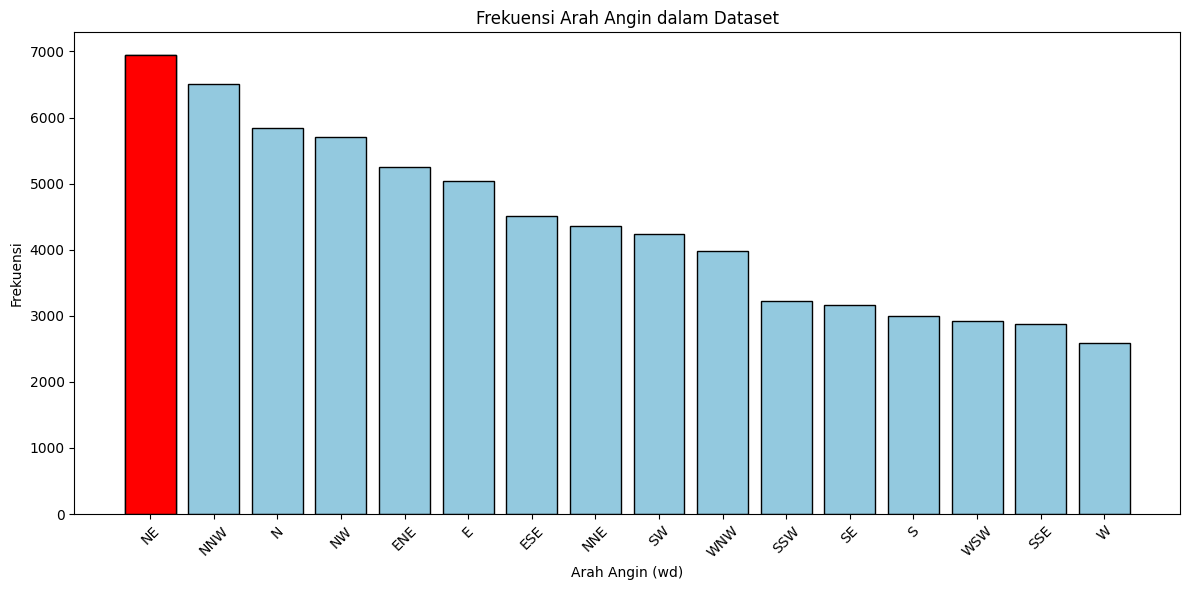

In [79]:
# Histogram
plt.figure(figsize=(12, 6))
wd_counts = Data_Polusi['wd'].value_counts()
colors = ['red' if count == wd_counts.max() else 'skyblue' for count in wd_counts]
wd_counts_df = wd_counts.reset_index()
wd_counts_df.columns = ['wd', 'frekuensi']

sns.barplot(x='wd', y='frekuensi', data=wd_counts_df,
            color='skyblue', edgecolor='black')
for i, count in enumerate(wd_counts_df['frekuensi']):
    if count == wd_counts.max():
        plt.bar(wd_counts_df['wd'][i], count, color='red', edgecolor='black')

plt.xlabel("Arah Angin (wd)")
plt.ylabel("Frekuensi")
plt.title("Frekuensi Arah Angin dalam Dataset")
plt.xticks(rotation=45)  # Memutar label sumbu x untuk kejelasan
plt.tight_layout()
plt.show()

Dapat dilihat dari plot diatas bahwa arah angin lebih dominan ke arah timur laut

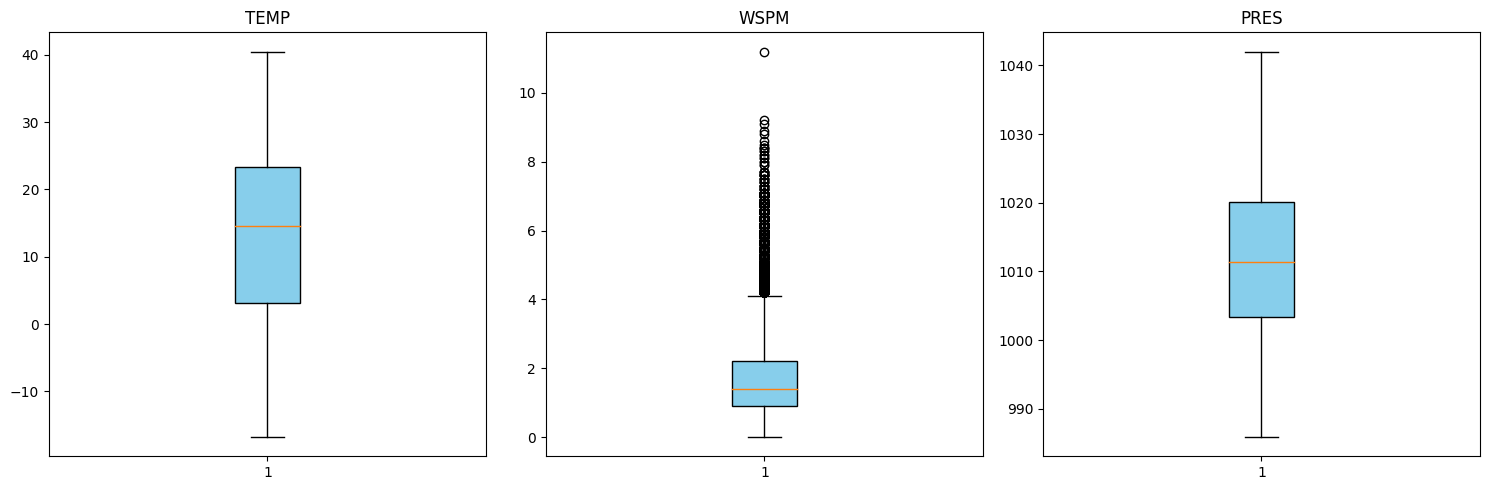

In [80]:
# Boxplot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
data_cuaca = ['TEMP', 'WSPM', 'PRES']
Datac = Data_Aotizhongxin[data_cuaca].dropna()
for i, ax in enumerate(axs):
    ax.boxplot(Datac[data_cuaca[i]], patch_artist=True, boxprops=dict(facecolor='skyblue'))
    ax.set_title(data_cuaca[i])
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Analisis multivariat


Text(0, 0.5, 'PM10')

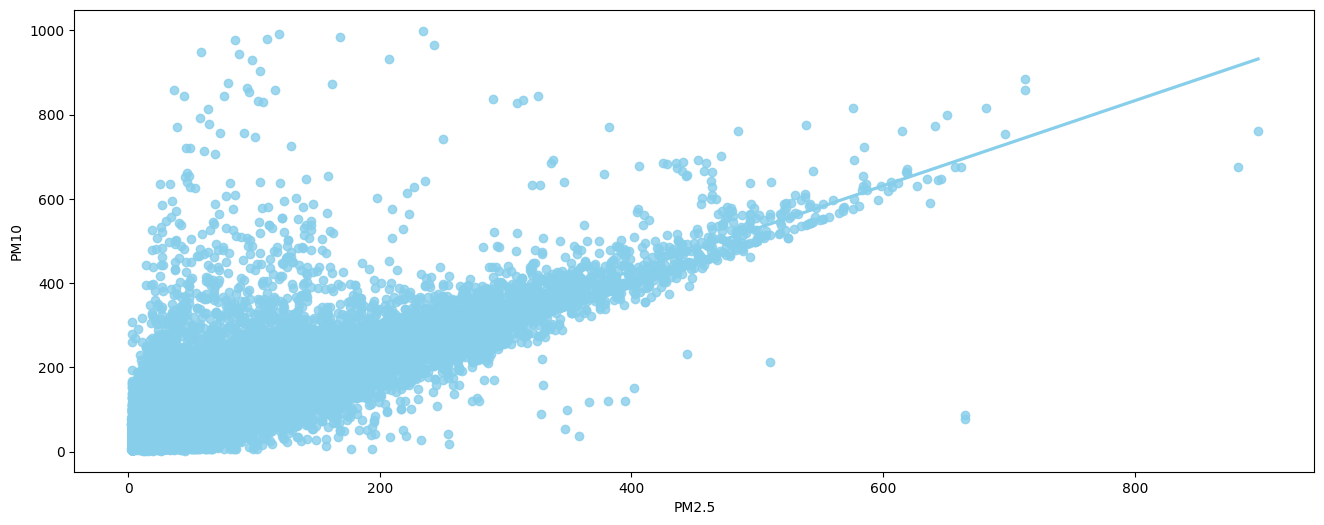

In [81]:
plt.figure(figsize=(16,6))
sns.regplot(x='PM2.5', y='PM10', data=Data_Polusi, color='skyblue')
plt.xlabel("PM2.5")
plt.ylabel("PM10")

Dapat dilihat dari plot diatas bahwa Terdapat hubungan yang cukup kuat antar kedua varibel(PM2.5 dan PM10)

In [ ]:
#line chart
plt.figure(figsize=(16, 6))
sns.lineplot(x="hour", y="NO2", data=Data_Polusi, color='Blue')
plt.xlabel("Hours")
plt.ylabel("NO2 (µg/Nm3)")
plt.title("Tren Kandungan NO2 di Udara per Jam")
plt.grid(True)
plt.tight_layout()
plt.show()

Berdasarkan plot diatas dapat dilihat bahwa jumlah NO2 akan menurun padaa siang hari dan kembali naik menjelang sore. Hal ini dapat terjadi karena pengaruh suhu tinggi yang memecah senyawa NO2.

### matriks korelasi dan heatmap

<Axes: >

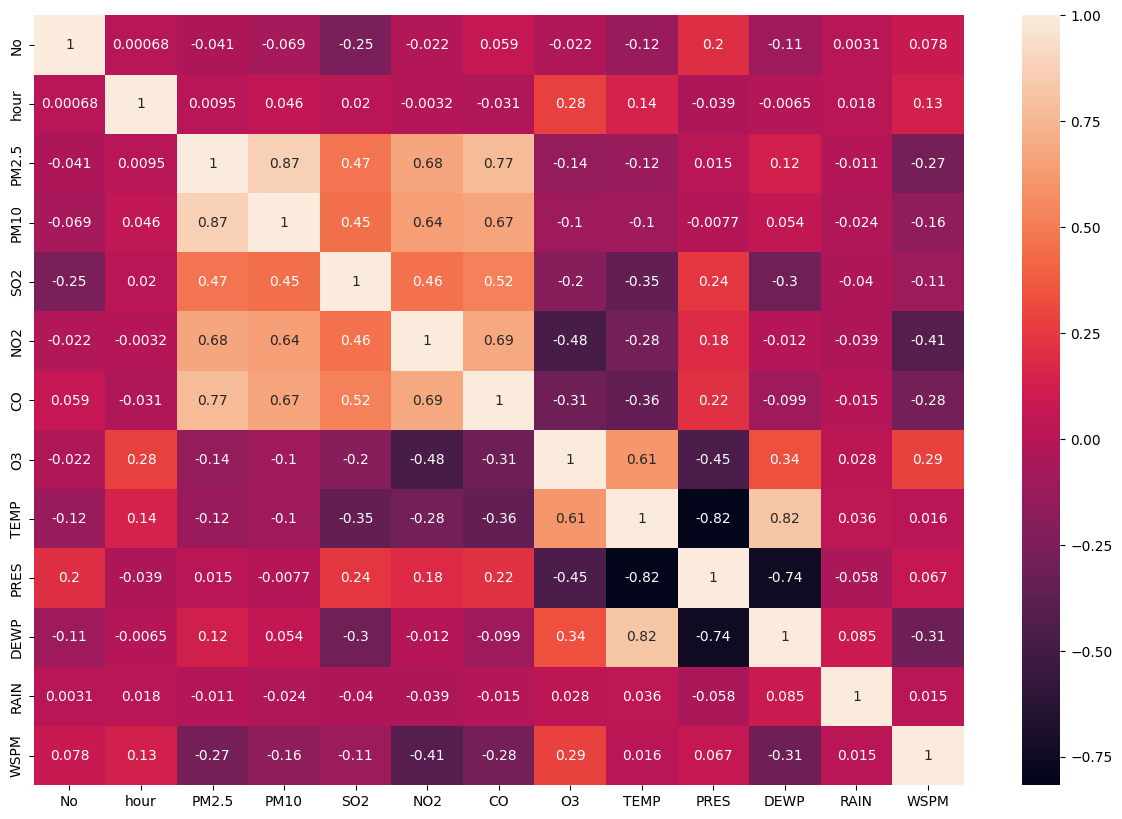

In [39]:
plt.figure(figsize=(15, 10))
sns.heatmap(Data_Polusi.corr(numeric_only=True), annot=True)

Berdasarjan plot diatas dapat dilihat adanya korelasi yang kuat antara variabel curah hujan dengan tingkat kelembapan udara, tekanan dengan suhu, serta terjadi korelasi negative yang cukup bermakna antar variabel NO2 dan CO terhadap O3.

# Menjawab pertanyaan dengan visualization dan Explanatory analysis

### 1. Bagaimana tren pencemaran udara di sekitar station?

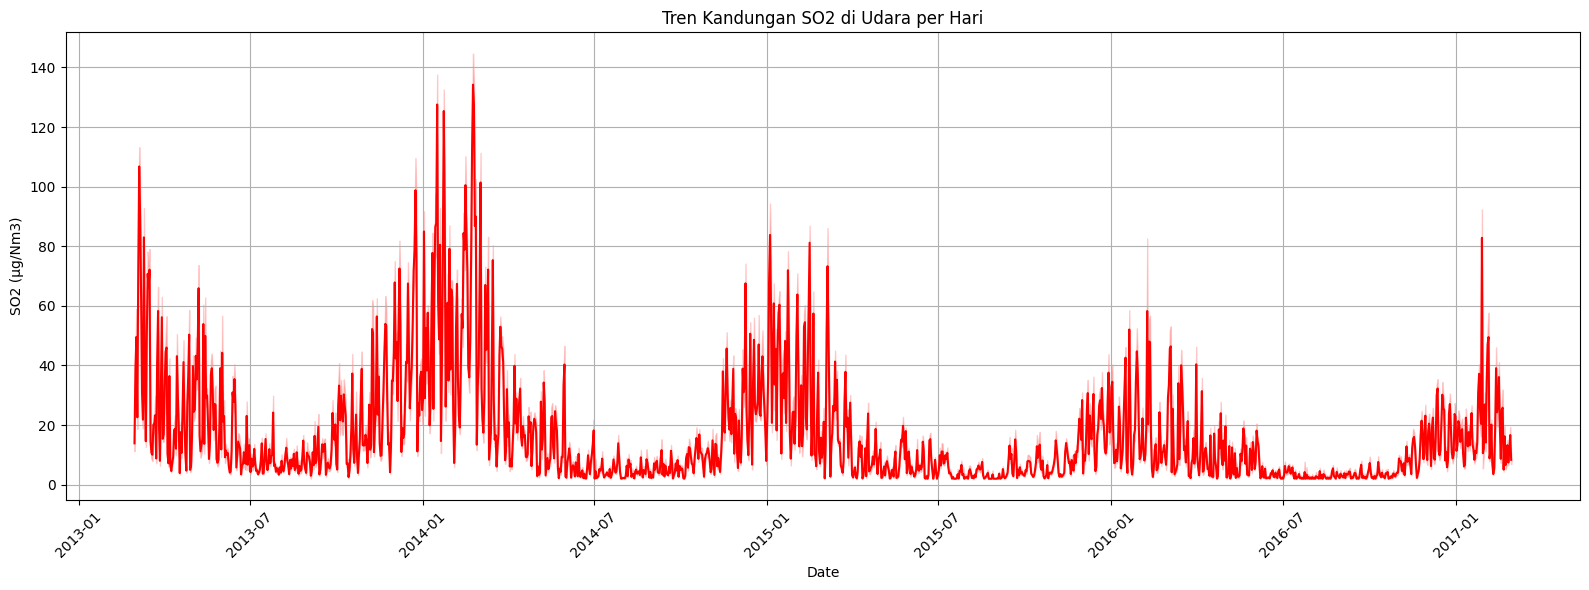

In [47]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="datetime", y="SO2", data=Data_Polusi, color='red')
plt.xlabel("Date")
plt.ylabel("SO2 (µg/Nm3)")
plt.title("Tren Kandungan SO2 di Udara per Hari")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



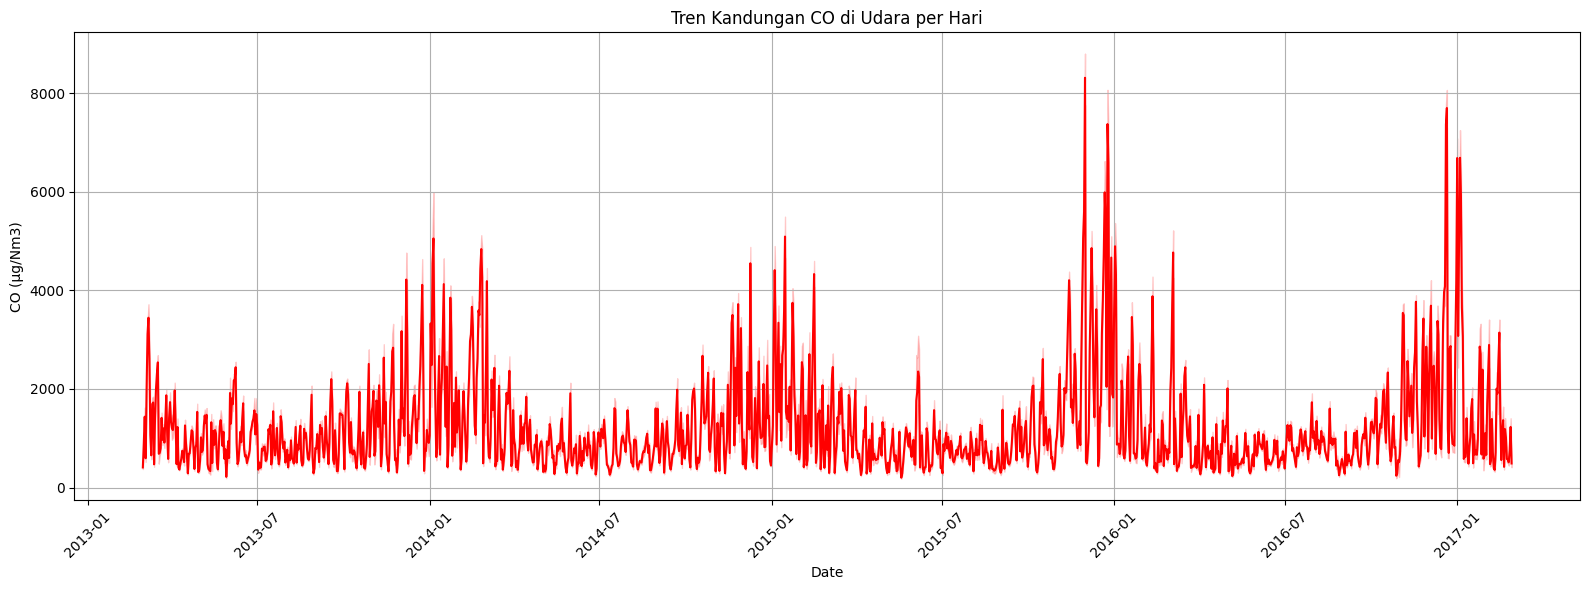

In [46]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="datetime", y="CO", data=Data_Polusi, color='red')
plt.xlabel("Date")
plt.ylabel("CO (µg/Nm3)")
plt.title("Tren Kandungan CO di Udara per Hari")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

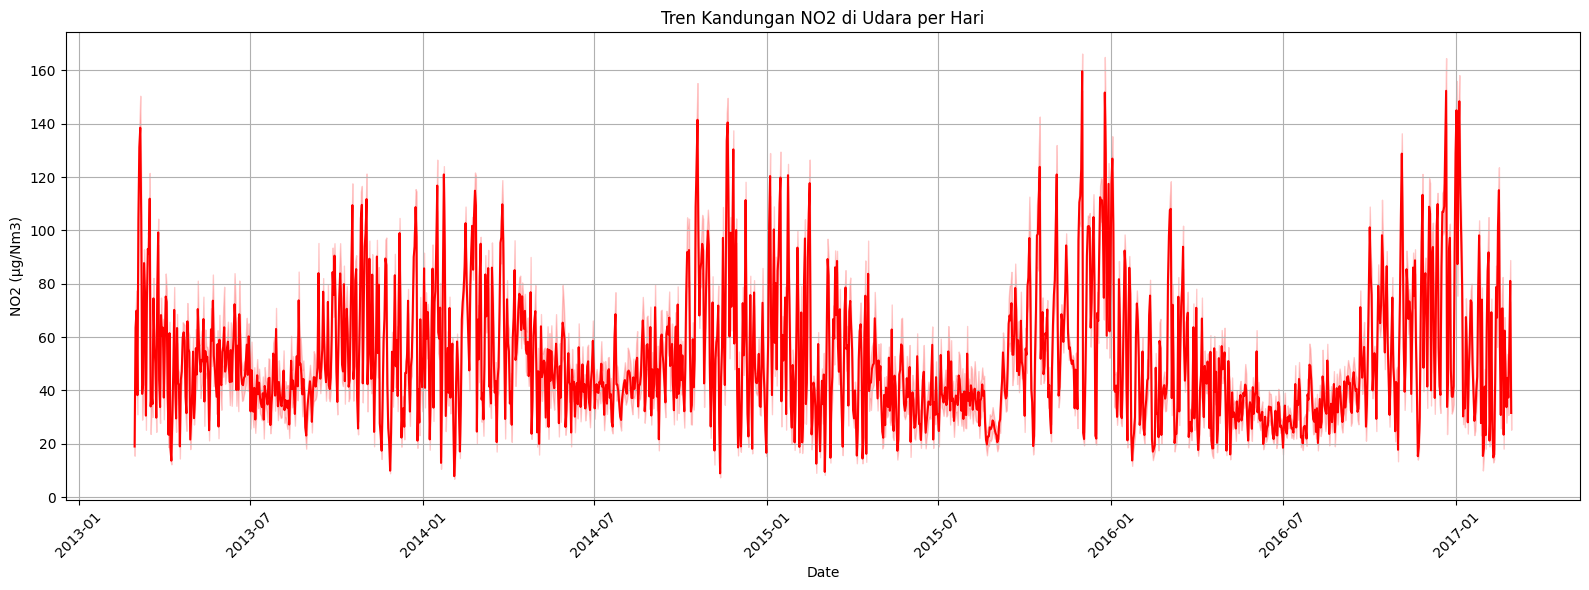

In [48]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="datetime", y="NO2", data=Data_Polusi, color='red')
plt.xlabel("Date")
plt.ylabel("NO2 (µg/Nm3)")
plt.title("Tren Kandungan NO2 di Udara per Hari")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

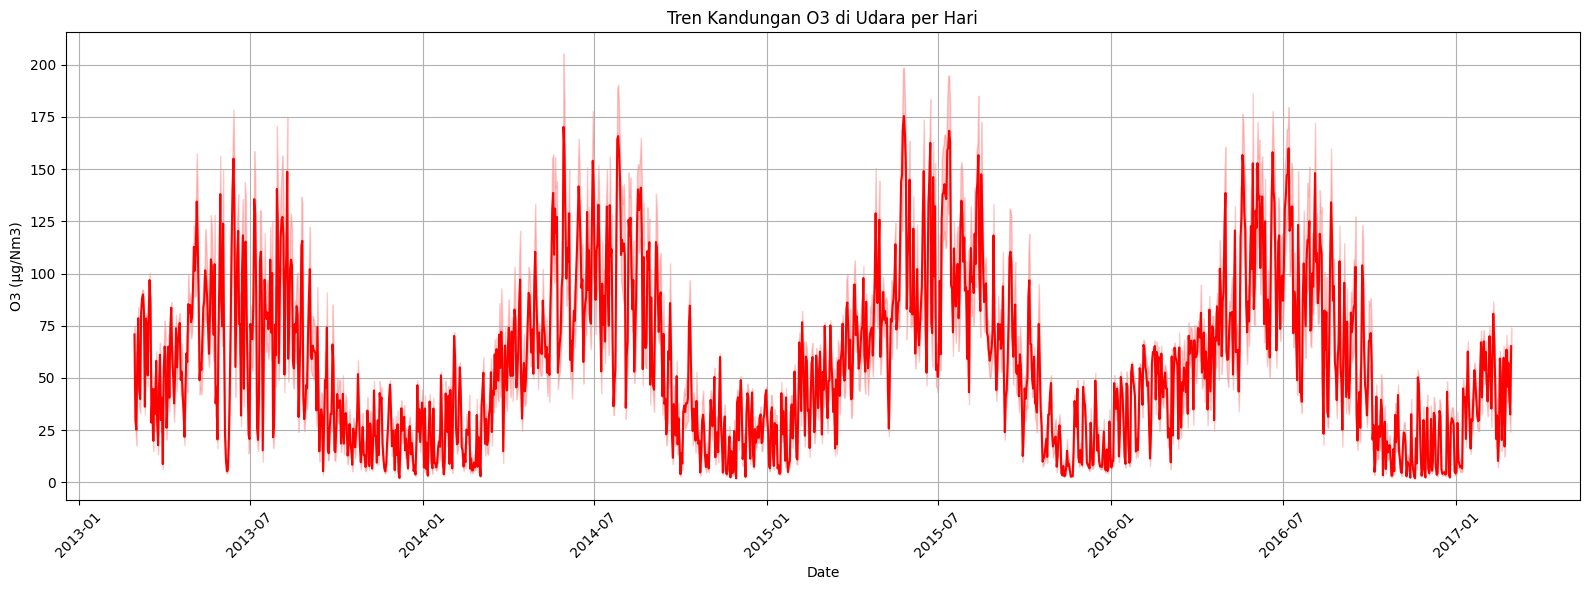

In [49]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="datetime", y="O3", data=Data_Polusi, color='red')
plt.xlabel("Date")
plt.ylabel("O3 (µg/Nm3)")
plt.title("Tren Kandungan O3 di Udara per Hari")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**kesimpulan:**
1. Terdapat tren pola kenaikan senyawa SO2, CO, dan NO2 setiap akhir tahun dan menurun pada awal tahun.
2. Hal sebaliknya tejadi pada O3 yang mengalami penurunan pada akhir tahun dan kenaikan pada awal tahun.

### 2. Pada musim apa polusi udara tertinggi?

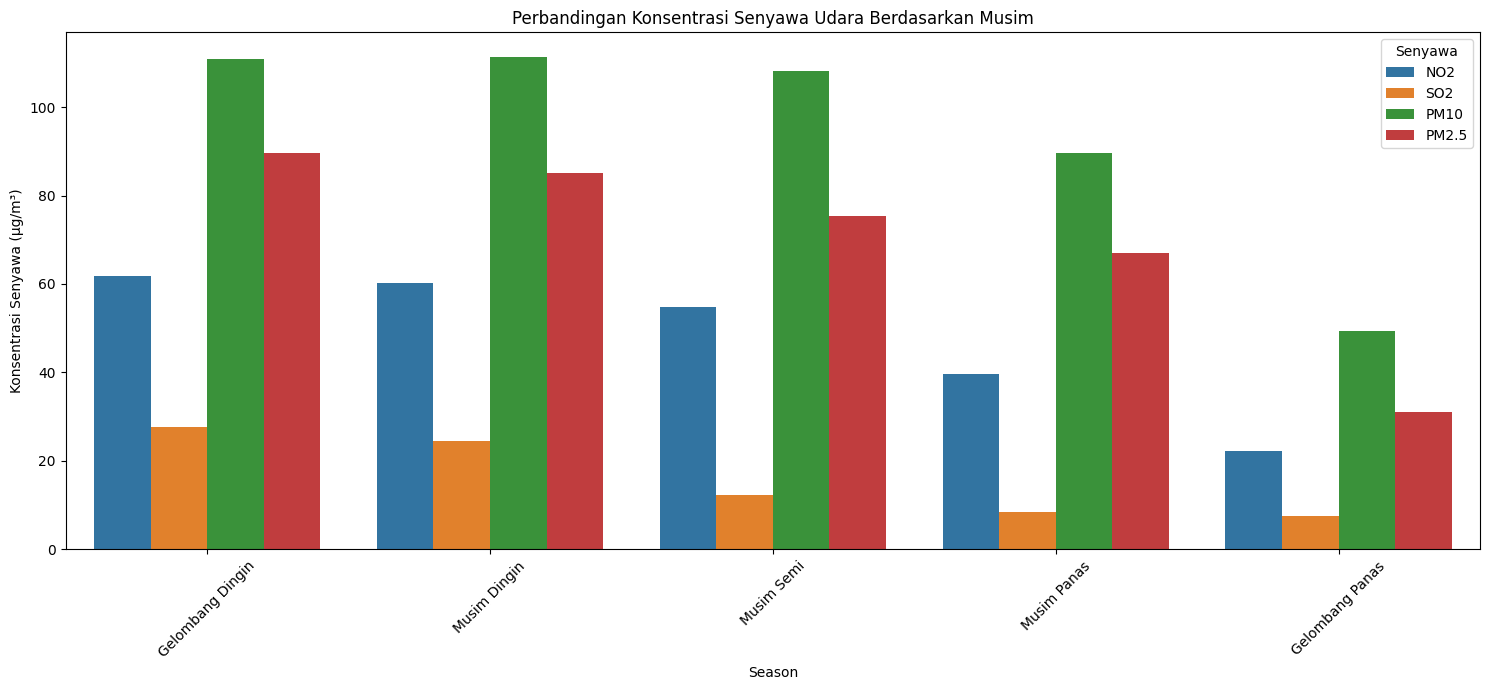

In [50]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
season_order = ['Gelombang Dingin', 'Musim Dingin', 'Musim Semi', 'Musim Panas', 'Gelombang Panas']
Data_Polusi = Data_Polusi.dropna(subset=['Season'] + ['NO2', 'SO2', 'PM10', 'PM2.5'])
senyawa = ['NO2', 'SO2', 'PM10', 'PM2.5']
data_senyawa = Data_Polusi.groupby('Season')[senyawa].mean().reindex(season_order)
data_senyawa_melted = data_senyawa.reset_index().melt(id_vars='Season', value_vars=senyawa, var_name='Senyawa', value_name='Konsentrasi')
plt.figure(figsize=(15, 7))
sns.barplot(x='Season', y='Konsentrasi', hue='Senyawa', data=data_senyawa_melted, order=season_order)
plt.xlabel("Season")
plt.ylabel("Konsentrasi Senyawa (µg/m³)")
plt.title("Perbandingan Konsentrasi Senyawa Udara Berdasarkan Musim")
plt.legend(title='Senyawa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**kesimpulan:**
1. Barplot di atas menunjukkan perbedaan jumlah senyawa dan partikel mikro yang menyebabkan polusi.
2. Pada gelombang dingin, variabel polusi menunjukkan pola tertinggi dibandingkan pada musim-musim yang lain.sebaliknya terjadi pada saat gelombang panas.
3. Pola yang dihasilkan juga mencerminkan bahwa variabel polusi cenderung dipengaruhi oleh suhu lingkungan.



### 3. Apakah ada perbedaan tingkat kualitas udara pada siang dan malam hari?


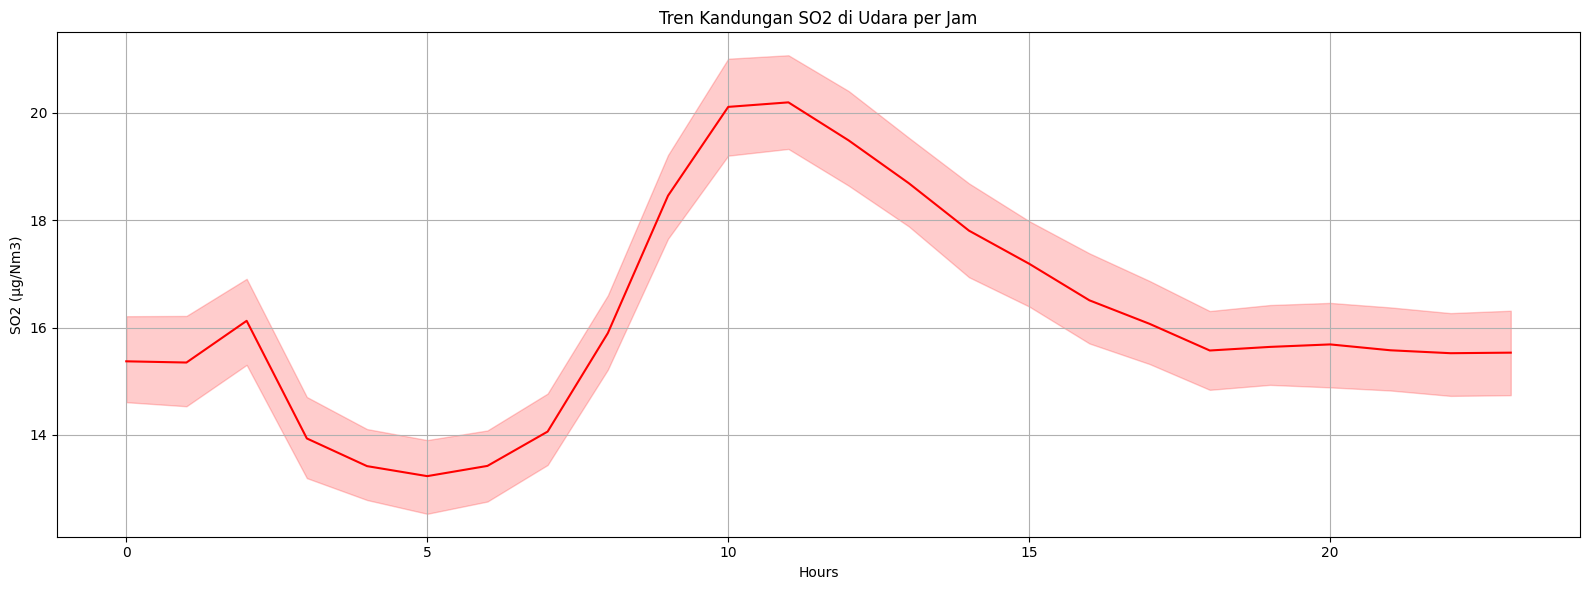

In [51]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="hour", y="SO2", data=Data_Polusi, color='red')
plt.xlabel("Hours")
plt.ylabel("SO2 (µg/Nm3)")
plt.title("Tren Kandungan SO2 di Udara per Jam")
plt.grid(True)
plt.tight_layout()
plt.show()

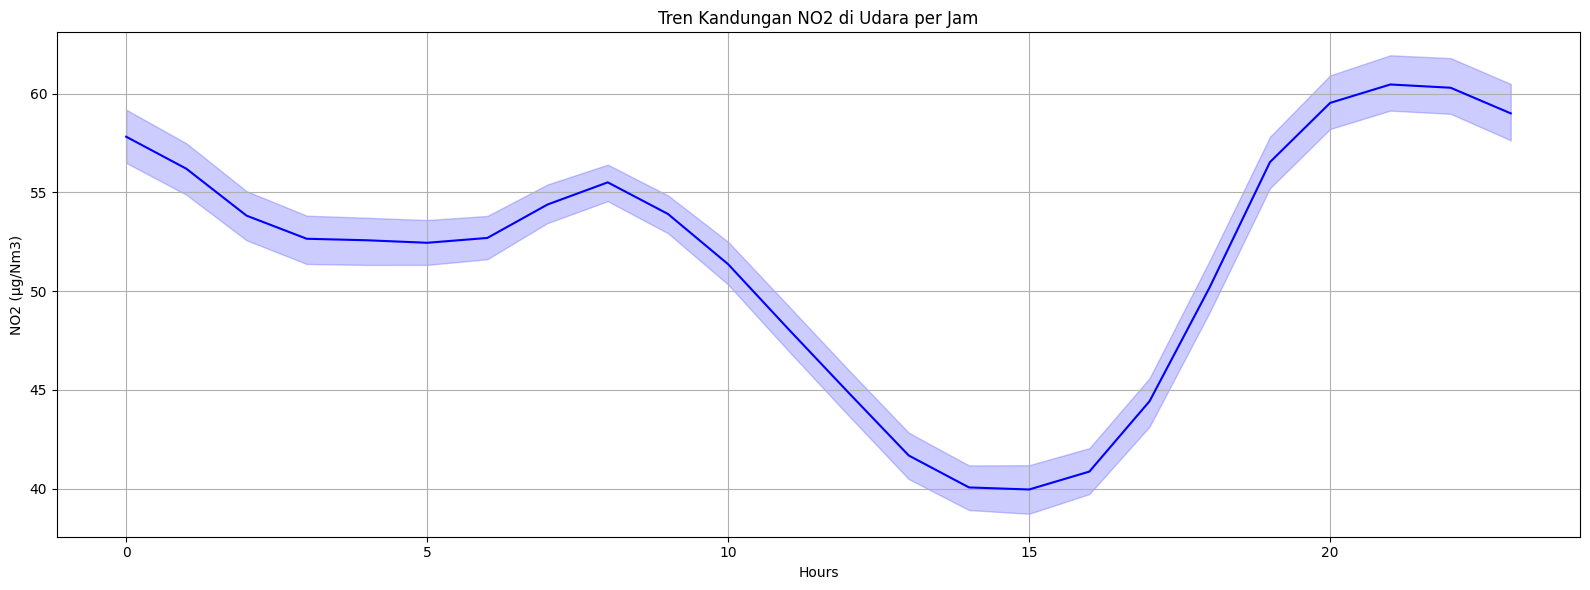

In [52]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="hour", y="NO2", data=Data_Polusi, color='Blue')
plt.xlabel("Hours")
plt.ylabel("NO2 (µg/Nm3)")
plt.title("Tren Kandungan NO2 di Udara per Jam")
plt.grid(True)
plt.tight_layout()
plt.show()

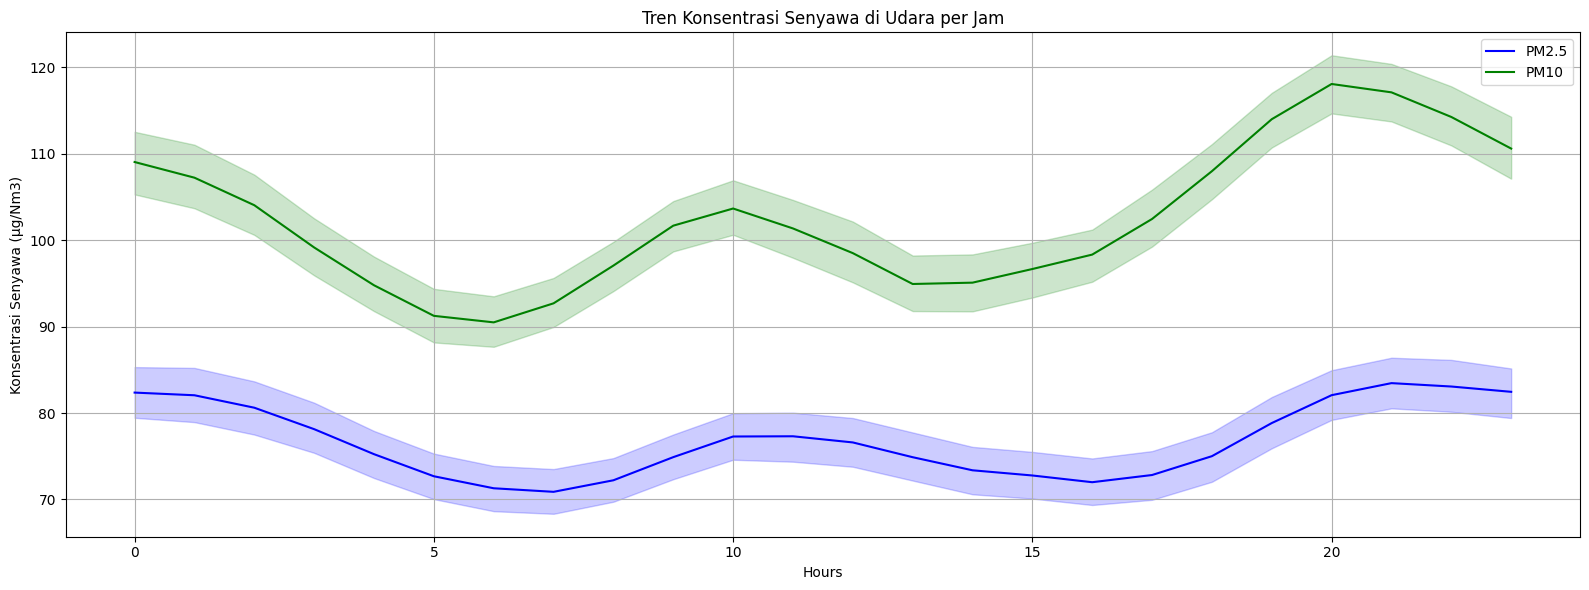

In [53]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="hour", y="PM2.5", data=Data_Polusi, color='blue', label='PM2.5')
sns.lineplot(x="hour", y="PM10", data=Data_Polusi, color='green', label='PM10')
plt.xlabel("Hours")
plt.ylabel("Konsentrasi Senyawa (µg/Nm3)")
plt.title("Tren Konsentrasi Senyawa di Udara per Jam")
plt.grid(True)
plt.tight_layout()
plt.show()

**Kesimpulan:**

1.  Kandungan dari setiap variabel polutan cenderung menurun pada waktu pagi dan kembali naik saat jam mulai kerja.
2. Pada siang hari, senyawa-senyawa ini cenderung menurun.

### 4. Apakah suhu berpartisipasi pada pembentukan ozon pada lapisan troposfer?

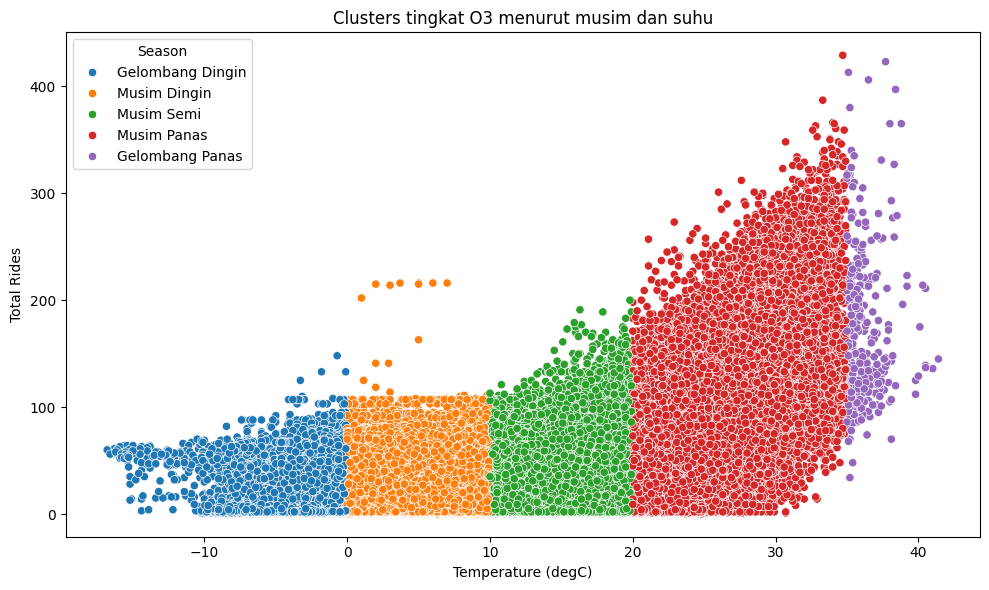

In [55]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='TEMP', y='O3', data=Data_Polusi, hue='Season')
plt.xlabel("Temperature (degC)")
plt.ylabel("Total Rides")
plt.title("Clusters tingkat O3 menurut musim dan suhu")
plt.tight_layout()
plt.show()

**kesimpulan**

Pada grafik di atas, ketika suhu lebih rendah, kandungan O3 di udara juga cenderung rendah. Ini terjadi selama musim dingin dan gelombang dingin, sedangkan ketika suhu lebih naik, kadnungan O3 akan meningkat. Hal ini cukup membuktikan bahwa suhu berpengaruh cukup kuat terhadap keberadaan senyawa O3 diudara.


# conclusion





Conclution Pertanyaan 1: Bagaimana tren pencemaran udara di sekitar station?
- Terdapat tren pola kenaikan senyawa SO2, CO, dan NO2 setiap akhir tahun dan menurun pada awal tahun.Hal sebaliknya tejadi pada O3 yang mengalami penurunan pada akhir tahun dan kenaikan pada awal tahun.

Conclution pertanyaan 2: Pada musim apa polusi udara tertinggi?
- Terdapat perbedaan jumlah senyawa dan partikel mikro yang menyebabkan polusi pada setiap musim. Pada gelombang dingin, variabel polusi menunjukkan pola tertinggi dibandingkan pada musim-musim yang lain.sebaliknya terjadi pada saat gelombang panas. Pola yang dihasilkan juga mencerminkan bahwa variabel polusi cenderung dipengaruhi oleh perubahan suhu lingkungan.

Conclution pertanyaan 3: Apakah ada perbedaan tingkat kualitas udara pada siang dan malam hari?
- Kandungan dari setiap variabel polutan cenderung menurun pada waktu pagi dan kembali naik saat jam mulai kerja. Pada siang hari, senyawa-senyawa ini cenderung menurun. namun akan kembali naik menjelang matahari terbenam(sore hari)

Conclution pertanyaan 4: Apakah suhu berpengaruh pada pembentukan ozon di lapisan troposfer?(menggunakan metode clustering)
- ketika suhu lebih rendah, kandungan O3 di udara juga cenderung rendah. Ini terjadi selama musim dingin dan gelombang dingin, sedangkan ketika suhu lebih tinggi, kadnungan O3 akan meningkat. Hal ini cukup membuktikan bahwa suhu berpengaruh cukup kuat terhadap keberadaan senyawa O3 diudara.

